In [1]:
import numpy as np
import pandas as pd
import time
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import yfinance as yf

np.random.seed(42)


## Joint ANN 與 Sort Bootstrap 工具

這一段定義二維 joint window、ANN 點預測模型，以及利用 rolling out-of-sample residual pool 搭配 sort bootstrap 建立預測區間的流程。


In [2]:
def component_correlation_summary(linear_part, nonlinear_part):
    linear_part = np.asarray(linear_part, dtype=float)
    nonlinear_part = np.asarray(nonlinear_part, dtype=float)

    if linear_part.shape != nonlinear_part.shape:
        raise ValueError("linear_part and nonlinear_part must have the same shape.")

    if linear_part.size < 2:
        return {
            "pearson_corr": np.nan,
            "abs_pearson_corr": np.nan,
            "corr_sq": np.nan,
            "covariance": np.nan,
        }

    pearson_corr = float(np.corrcoef(linear_part, nonlinear_part)[0, 1])
    covariance = float(np.cov(linear_part, nonlinear_part, ddof=1)[0, 1])
    return {
        "pearson_corr": pearson_corr,
        "abs_pearson_corr": abs(pearson_corr),
        "corr_sq": pearson_corr ** 2,
        "covariance": covariance,
    }


def kalman_filter(observations, process_variance=0.5, measurement_variance=10.0, initial_error=1.0):
    initial_estimate = float(observations[0])
    estimated_state = initial_estimate
    estimate_error = float(initial_error)
    estimated_states = []

    for measurement in observations:
        predicted_state = estimated_state
        predicted_error = estimate_error + process_variance

        kalman_gain = predicted_error / (predicted_error + measurement_variance)
        estimated_state = predicted_state + kalman_gain * (measurement - predicted_state)
        estimate_error = (1.0 - kalman_gain) * predicted_error
        estimated_states.append(estimated_state)

    return np.array(estimated_states, dtype=float)


def decompose_with_simple_kf(series, process_variance=0.5, measurement_variance=10.0):
    estimated_low = kalman_filter(
        series,
        process_variance=process_variance,
        measurement_variance=measurement_variance,
        initial_error=1.0,
    )
    estimated_high = np.array(series, dtype=float) - estimated_low
    return estimated_low, estimated_high


In [3]:
def create_joint_windows(low_series, high_series, window_size):
    features = []
    targets = []
    for idx in range(window_size, len(low_series)):
        low_window = np.asarray(low_series[idx - window_size:idx], dtype=float)
        high_window = np.asarray(high_series[idx - window_size:idx], dtype=float)
        joint_window = np.column_stack([low_window, high_window]).reshape(-1)
        features.append(joint_window)
        targets.append([float(low_series[idx]), float(high_series[idx])])
    return np.asarray(features, dtype=float), np.asarray(targets, dtype=float)


class JointANNRegressor(nn.Module):
    def __init__(self, input_dim, hidden_size):
        super().__init__()
        hidden_2 = max(hidden_size // 2, 8)
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_2),
            nn.ReLU(),
            nn.Linear(hidden_2, 2),
        )

    def forward(self, x):
        return self.net(x)


def fit_joint_ann_bundle(low_train, high_train, window_size, hidden_size=32, epochs=250, learning_rate=1e-3):
    x_train, y_train = create_joint_windows(low_train, high_train, window_size)
    if len(x_train) == 0:
        raise ValueError("Not enough samples for joint ANN windows. Increase training size or reduce window_size.")

    x_scaler = StandardScaler()
    y_scaler = StandardScaler()
    x_train_scaled = x_scaler.fit_transform(x_train).astype(np.float32)
    y_train_scaled = y_scaler.fit_transform(y_train).astype(np.float32)

    x_tensor = torch.tensor(x_train_scaled, dtype=torch.float32)
    y_tensor = torch.tensor(y_train_scaled, dtype=torch.float32)

    model = JointANNRegressor(input_dim=x_train.shape[1], hidden_size=hidden_size)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.MSELoss()
    loss_history = []

    model.train()
    for _ in range(epochs):
        optimizer.zero_grad()
        pred = model(x_tensor)
        loss = criterion(pred, y_tensor)
        loss.backward()
        optimizer.step()
        loss_history.append(float(loss.item()))

    low_q = np.quantile(low_train, [0.01, 0.99])
    high_q = np.quantile(high_train, [0.01, 0.99])
    low_iqr = np.subtract(*np.quantile(low_train, [0.75, 0.25]))
    high_iqr = np.subtract(*np.quantile(high_train, [0.75, 0.25]))
    low_margin = max(0.5 * low_iqr, 0.25)
    high_margin = max(0.5 * high_iqr, 0.25)
    clip_bounds = (
        (float(low_q[0] - low_margin), float(low_q[1] + low_margin)),
        (float(high_q[0] - high_margin), float(high_q[1] + high_margin)),
    )

    return {
        "model": model.eval(),
        "x_scaler": x_scaler,
        "y_scaler": y_scaler,
        "clip_bounds": clip_bounds,
        "window_size": window_size,
        "hidden_size": hidden_size,
        "loss_history": loss_history,
        "final_loss": loss_history[-1] if loss_history else np.nan,
    }


def recursive_joint_ann_forecast(bundle, low_history, high_history, horizon):
    model = bundle["model"]
    x_scaler = bundle["x_scaler"]
    y_scaler = bundle["y_scaler"]
    window_size = bundle["window_size"]
    (low_min, low_max), (high_min, high_max) = bundle["clip_bounds"]

    low_hist = list(map(float, low_history))
    high_hist = list(map(float, high_history))
    low_forecast = np.zeros(horizon, dtype=float)
    high_forecast = np.zeros(horizon, dtype=float)

    for step in range(horizon):
        low_window = np.asarray(low_hist[-window_size:], dtype=float)
        high_window = np.asarray(high_hist[-window_size:], dtype=float)
        joint_window = np.column_stack([low_window, high_window]).reshape(1, -1)
        joint_window_scaled = x_scaler.transform(joint_window)
        x_tensor = torch.tensor(joint_window_scaled, dtype=torch.float32)

        with torch.no_grad():
            pred_scaled = model(x_tensor).cpu().numpy()

        pred = y_scaler.inverse_transform(pred_scaled)[0]
        next_low = float(np.clip(pred[0], low_min, low_max))
        next_high = float(np.clip(pred[1], high_min, high_max))
        low_forecast[step] = next_low
        high_forecast[step] = next_high

        low_hist.append(next_low)
        high_hist.append(next_high)

    return low_forecast, high_forecast


def fit_joint_ann_component(low_train, high_train, horizon, window_size, hidden_size=32):
    bundle = fit_joint_ann_bundle(
        low_train,
        high_train,
        window_size=window_size,
        hidden_size=hidden_size,
    )
    low_forecast, high_forecast = recursive_joint_ann_forecast(
        bundle,
        low_train,
        high_train,
        horizon=horizon,
    )
    return low_forecast, high_forecast, bundle


def hybrid_point_forecast(train_series, horizon, window_size=15, hidden_size=32):
    estimated_low, estimated_high = decompose_with_simple_kf(train_series)
    low_forecast, high_forecast, bundle = fit_joint_ann_component(
        estimated_low,
        estimated_high,
        horizon,
        window_size=window_size,
        hidden_size=hidden_size,
    )
    final_forecast = low_forecast + high_forecast

    return {
        "estimated_low": estimated_low,
        "estimated_high": estimated_high,
        "low_forecast": low_forecast,
        "high_forecast": high_forecast,
        "joint_bundle": bundle,
        "final_forecast": final_forecast,
    }


def timed_hybrid_point_forecast(train_series, horizon, window_size=15, hidden_size=32):
    timing = {
        "kf_decomposition": 0.0,
        "joint_ann_fit_forecast": 0.0,
    }

    kf_start = time.perf_counter()
    estimated_low, estimated_high = decompose_with_simple_kf(train_series)
    timing["kf_decomposition"] += time.perf_counter() - kf_start

    ann_start = time.perf_counter()
    low_forecast, high_forecast, bundle = fit_joint_ann_component(
        estimated_low,
        estimated_high,
        horizon,
        window_size=window_size,
        hidden_size=hidden_size,
    )
    timing["joint_ann_fit_forecast"] += time.perf_counter() - ann_start

    final_forecast = low_forecast + high_forecast

    return {
        "estimated_low": estimated_low,
        "estimated_high": estimated_high,
        "low_forecast": low_forecast,
        "high_forecast": high_forecast,
        "joint_bundle": bundle,
        "final_forecast": final_forecast,
    }, timing


def sort_bootstrap_residuals(residual_pool, horizon, rng):
    sampled_indices = rng.choice(len(residual_pool), size=horizon, replace=True)
    sampled_indices.sort()
    return residual_pool[sampled_indices]


def rolling_oos_residual_pool(series, window_size, hidden_size=32, min_train_size=None):
    series = np.asarray(series, dtype=float)
    if min_train_size is None:
        min_train_size = max(window_size + 20, window_size + 5)

    residuals = []
    for split_end in range(min_train_size, len(series)):
        train_prefix = series[:split_end]
        actual_next = float(series[split_end])
        point_bundle, _ = timed_hybrid_point_forecast(
            train_prefix,
            1,
            window_size=window_size,
            hidden_size=hidden_size,
        )
        residuals.append(actual_next - float(point_bundle["final_forecast"][0]))

    if not residuals:
        raise ValueError("Rolling out-of-sample residual pool is empty. Increase training size or reduce window_size.")

    residuals = np.asarray(residuals, dtype=float)
    return residuals - float(np.mean(residuals))


def sort_bootstrap_prediction_interval(point_forecast, residual_pool, bootstrap_replications=300, alpha=0.05, random_seed=123):
    point_forecast = np.asarray(point_forecast, dtype=float)
    horizon = len(point_forecast)
    rng = np.random.default_rng(random_seed)
    bootstrap_paths = np.zeros((bootstrap_replications, horizon), dtype=float)

    for boot_idx in range(bootstrap_replications):
        sampled_residuals = sort_bootstrap_residuals(residual_pool, horizon, rng)
        bootstrap_paths[boot_idx, :] = point_forecast + sampled_residuals

    interval_lower = np.quantile(bootstrap_paths, alpha / 2, axis=0)
    interval_upper = np.quantile(bootstrap_paths, 1 - alpha / 2, axis=0)
    return interval_lower, interval_upper, bootstrap_paths


## 繪圖工具

這一段提供互動圖與 component 相關性圖的繪製函式，用來觀察線性與非線性部分之間的關係。

In [4]:
def save_interaction_plot(bundle, low_history, high_history, output_path, grid_points=41):
    window_size = bundle["window_size"]
    ensemble_size = bundle["ensemble_size"]
    base_low = np.asarray(low_history[-window_size:], dtype=float)
    base_high = np.asarray(high_history[-window_size:], dtype=float)

    low_min, low_max = bundle["clip_bounds"][0]
    high_min, high_max = bundle["clip_bounds"][1]
    low_grid = np.linspace(low_min, low_max, grid_points)
    high_grid = np.linspace(high_min, high_max, grid_points)

    mean_surface = np.zeros((grid_points, grid_points), dtype=float)
    width_surface = np.zeros((grid_points, grid_points), dtype=float)

    for i, low_val in enumerate(low_grid):
        for j, high_val in enumerate(high_grid):
            low_window = base_low.copy()
            high_window = base_high.copy()
            low_window[-1] = low_val
            high_window[-1] = high_val

            features = np.column_stack([low_window, high_window]).reshape(1, -1)
            features = np.repeat(features, ensemble_size, axis=0)
            features_scaled = bundle["x_scaler"].transform(features)
            with torch.no_grad():
                pred_scaled = bundle["model"](torch.tensor(features_scaled, dtype=torch.float32)).cpu().numpy()

            diag_scaled = pred_scaled[np.arange(ensemble_size), np.arange(ensemble_size), :]
            diag_pred = bundle["y_scaler"].inverse_transform(diag_scaled)
            next_low = np.clip(diag_pred[:, 0], bundle["clip_bounds"][0][0], bundle["clip_bounds"][0][1])
            next_high = np.clip(diag_pred[:, 1], bundle["clip_bounds"][1][0], bundle["clip_bounds"][1][1])
            final_samples = next_low + next_high

            mean_surface[j, i] = np.mean(final_samples)
            width_surface[j, i] = np.quantile(final_samples, 0.975) - np.quantile(final_samples, 0.025)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    mean_im = axes[0].imshow(
        mean_surface,
        origin="lower",
        aspect="auto",
        extent=[low_grid[0], low_grid[-1], high_grid[0], high_grid[-1]],
        cmap="viridis",
    )
    axes[0].set_title("Final Mean vs Last (L,H)")
    axes[0].set_xlabel("Last L")
    axes[0].set_ylabel("Last H")
    fig.colorbar(mean_im, ax=axes[0], shrink=0.85)

    width_im = axes[1].imshow(
        width_surface,
        origin="lower",
        aspect="auto",
        extent=[low_grid[0], low_grid[-1], high_grid[0], high_grid[-1]],
        cmap="magma",
    )
    axes[1].set_title("Final 95% Width vs Last (L,H)")
    axes[1].set_xlabel("Last L")
    axes[1].set_ylabel("Last H")
    fig.colorbar(width_im, ax=axes[1], shrink=0.85)

    fig.tight_layout()
    fig.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.close(fig)


def save_component_correlation_plot(true_low, true_high, estimated_low, estimated_high, output_path):
    fig, axes = plt.subplots(2, 2, figsize=(11, 9))

    true_corr = component_correlation_summary(true_low, true_high)
    estimated_corr = component_correlation_summary(estimated_low, estimated_high)

    axes[0, 0].plot(true_low, label="True linear", linewidth=1.5)
    axes[0, 0].plot(true_high, label="True nonlinear", linewidth=1.2)
    axes[0, 0].set_title(f"Generated components (corr={true_corr['pearson_corr']:.3f})")
    axes[0, 0].legend()

    axes[0, 1].scatter(true_low, true_high, s=12, alpha=0.7)
    axes[0, 1].set_title("Generated linear vs nonlinear")
    axes[0, 1].set_xlabel("True linear")
    axes[0, 1].set_ylabel("True nonlinear")

    axes[1, 0].plot(estimated_low, label="KF linear", linewidth=1.5)
    axes[1, 0].plot(estimated_high, label="KF nonlinear", linewidth=1.2)
    axes[1, 0].set_title(f"KF components (corr={estimated_corr['pearson_corr']:.3f})")
    axes[1, 0].legend()

    axes[1, 1].scatter(estimated_low, estimated_high, s=12, alpha=0.7, color="tab:orange")
    axes[1, 1].set_title("KF linear vs KF nonlinear")
    axes[1, 1].set_xlabel("KF linear")
    axes[1, 1].set_ylabel("KF nonlinear")

    fig.tight_layout()
    fig.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.close(fig)


## 0050資料單次實驗函式

這一段使用 0050 從 2025-01-01 到 2025-12-31 收盤價當訓練資料，拿 2026-01-01 到 2026-05-31 的實際收盤價檢查預測準確性，並先用單次實驗來看對照的預測

In [5]:
def load_0050_actual_data(
    ticker="0050.TW",
    train_start="2025-01-01",
    train_end="2025-12-31",
    test_start="2026-01-01",
    test_end="2026-05-31",
):

    download_end = (pd.Timestamp(test_end) + pd.Timedelta(days=1)).strftime("%Y-%m-%d")
    raw = yf.download(
        ticker,
        start=train_start,
        end=download_end,
        auto_adjust=True,
        progress=False,
    )
    if raw.empty:
        raise ValueError(f"No market data downloaded for {ticker}.")

    close = raw["Close"]
    if isinstance(close, pd.DataFrame):
        close = close.iloc[:, 0]
    close = close.dropna().astype(float)

    train_close = close.loc[train_start:train_end]
    test_close = close.loc[test_start:test_end]
    if train_close.empty:
        raise ValueError(f"No training data found between {train_start} and {train_end} for {ticker}.")
    if test_close.empty:
        raise ValueError(f"No test data found between {test_start} and {test_end} for {ticker}.")

    full_close = pd.concat([train_close, test_close])
    return {
        "ticker": ticker,
        "train_period": f"{train_start} to {train_end}",
        "test_period": f"{test_start} to {test_end}",
        "full_dates": pd.to_datetime(full_close.index),
        "train_dates": pd.to_datetime(train_close.index),
        "test_dates": pd.to_datetime(test_close.index),
        "full_series": full_close.to_numpy(dtype=float),
        "train_series": train_close.to_numpy(dtype=float),
        "test_series": test_close.to_numpy(dtype=float),
    }


def evaluate_validation_split(train_prefix, valid_actual, window_size, hidden_size, bootstrap_replications=300):
    split_horizon = len(valid_actual)
    bundle, timing = timed_hybrid_point_forecast(
        train_prefix,
        split_horizon,
        window_size=window_size,
        hidden_size=hidden_size,
    )

    residual_pool = rolling_oos_residual_pool(
        train_prefix,
        window_size=window_size,
        hidden_size=hidden_size,
    )
    interval_lower, interval_upper, _ = sort_bootstrap_prediction_interval(
        bundle["final_forecast"],
        residual_pool,
        bootstrap_replications=bootstrap_replications,
        alpha=0.05,
        random_seed=123,
    )

    mse = float(np.mean((bundle["final_forecast"] - valid_actual) ** 2))
    rmse = float(np.sqrt(mse))
    std = float(np.std(valid_actual, ddof=1)) if len(valid_actual) > 1 else 0.0
    normalized_rmse = rmse / max(std, 1e-8)
    coverage = float(np.mean((valid_actual >= interval_lower) & (valid_actual <= interval_upper)) * 100.0)
    width = float(np.mean(interval_upper - interval_lower))

    return {
        "mse": mse,
        "rmse": rmse,
        "normalized_rmse": normalized_rmse,
        "coverage": coverage,
        "interval_width": width,
        "timing": timing,
    }


def rolling_validation_splits(train_series, initial_train_size=120, validation_horizon=10, step_size=10):
    train_series = np.asarray(train_series, dtype=float)
    splits = []
    split_end = initial_train_size
    while split_end + validation_horizon <= len(train_series):
        train_prefix = train_series[:split_end]
        valid_actual = train_series[split_end:split_end + validation_horizon]
        splits.append((train_prefix, valid_actual))
        split_end += step_size
    return splits


def grid_search_rolling_validation(
    train_series,
    window_grid,
    hidden_grid,
    initial_train_size=120,
    validation_horizon=10,
    step_size=10,
    bootstrap_replications=300,
):
    splits = rolling_validation_splits(
        train_series,
        initial_train_size=initial_train_size,
        validation_horizon=validation_horizon,
        step_size=step_size,
    )
    if not splits:
        raise ValueError("No rolling validation splits were created. Reduce initial_train_size or validation_horizon.")

    rows = []
    for window_size in window_grid:
        for hidden_size in hidden_grid:
            split_metrics = []
            for split_train, split_valid in splits:
                if len(split_train) <= window_size:
                    continue
                split_metrics.append(
                    evaluate_validation_split(
                        split_train,
                        split_valid,
                        window_size=window_size,
                        hidden_size=hidden_size,
                        bootstrap_replications=bootstrap_replications,
                    )
                )

            if not split_metrics:
                continue

            rows.append(
                {
                    "window_size": window_size,
                    "hidden_size": hidden_size,
                    "n_splits": len(split_metrics),
                    "mean_validation_mse": float(np.mean([m["mse"] for m in split_metrics])),
                    "mean_validation_rmse": float(np.mean([m["rmse"] for m in split_metrics])),
                    "mean_validation_nrmse": float(np.mean([m["normalized_rmse"] for m in split_metrics])),
                    "mean_validation_coverage": float(np.mean([m["coverage"] for m in split_metrics])),
                    "mean_validation_interval_width": float(np.mean([m["interval_width"] for m in split_metrics])),
                }
            )

    if not rows:
        raise ValueError("Grid search produced no valid configuration.")

    tuning_table = pd.DataFrame(rows).sort_values(
        by=["mean_validation_mse", "mean_validation_nrmse"],
        ascending=[True, True],
    ).reset_index(drop=True)
    best_row = tuning_table.iloc[0]
    best_params = {
        "window_size": int(best_row["window_size"]),
        "hidden_size": int(best_row["hidden_size"]),
    }
    return tuning_table, best_params


def run_single_experiment(
    window_size=15,
    hidden_size=32,
    bootstrap_replications=300,
    ticker="0050.TW",
    train_start="2025-01-01",
    train_end="2025-12-31",
    test_start="2026-01-01",
    test_end="2026-05-31",
    market_data=None,
    validation_summary=None,
):
    timing_info = {
        "data_generation": 0.0,
        "point_forecast_fit": 0.0,
        "kf_decomposition": 0.0,
        "joint_ann_fit_forecast": 0.0,
        "residual_pool_build": 0.0,
        "sort_bootstrap_interval": 0.0,
    }

    if market_data is None:
        data_start = time.perf_counter()
        market_data = load_0050_actual_data(
            ticker=ticker,
            train_start=train_start,
            train_end=train_end,
            test_start=test_start,
            test_end=test_end,
        )
        timing_info["data_generation"] += time.perf_counter() - data_start

    measurements = market_data["full_series"]
    train_series = market_data["train_series"]
    measurements_test = market_data["test_series"]
    train_size = len(train_series)
    horizon = len(measurements_test)

    estimated_low_full, estimated_high_full = decompose_with_simple_kf(measurements)
    kf_component_corr = component_correlation_summary(estimated_low_full, estimated_high_full)
    reference_low_test = estimated_low_full[train_size:]
    reference_high_test = estimated_high_full[train_size:]

    point_start = time.perf_counter()
    full_train_bundle, point_timing = timed_hybrid_point_forecast(
        train_series,
        horizon,
        window_size=window_size,
        hidden_size=hidden_size,
    )
    timing_info["point_forecast_fit"] += time.perf_counter() - point_start
    timing_info["kf_decomposition"] += point_timing["kf_decomposition"]
    timing_info["joint_ann_fit_forecast"] += point_timing["joint_ann_fit_forecast"]

    low_forecast = full_train_bundle["low_forecast"]
    high_forecast = full_train_bundle["high_forecast"]
    final_forecast = full_train_bundle["final_forecast"]

    pool_start = time.perf_counter()
    residual_pool = rolling_oos_residual_pool(
        train_series,
        window_size=window_size,
        hidden_size=hidden_size,
    )
    timing_info["residual_pool_build"] += time.perf_counter() - pool_start

    boot_start = time.perf_counter()
    interval_lower, interval_upper, bootstrap_paths = sort_bootstrap_prediction_interval(
        final_forecast,
        residual_pool,
        bootstrap_replications=bootstrap_replications,
        alpha=0.05,
        random_seed=123,
    )
    timing_info["sort_bootstrap_interval"] += time.perf_counter() - boot_start

    low_mse = np.mean((low_forecast - reference_low_test) ** 2)
    high_mse = np.mean((high_forecast - reference_high_test) ** 2)
    final_noisy_mse = np.mean((final_forecast - measurements_test) ** 2)
    final_noisy_rmse = float(np.sqrt(final_noisy_mse))
    test_std = float(np.std(measurements_test, ddof=1))
    normalized_rmse = final_noisy_rmse / max(test_std, 1e-8)
    sample_median_forecast = np.median(bootstrap_paths, axis=0)
    sample_path_mse = np.mean((bootstrap_paths - measurements_test.reshape(1, -1)) ** 2, axis=1)
    best_path_idx = int(np.argmin(sample_path_mse))
    best_path_forecast = bootstrap_paths[best_path_idx]
    noisy_in_interval = (measurements_test >= interval_lower) & (measurements_test <= interval_upper)
    noisy_coverage = np.mean(noisy_in_interval) * 100
    mean_interval_width = np.mean(interval_upper - interval_lower)

    return {
        "low_mse": low_mse,
        "high_mse": high_mse,
        "final_noisy_mse": final_noisy_mse,
        "final_noisy_rmse": final_noisy_rmse,
        "test_std": test_std,
        "normalized_rmse": normalized_rmse,
        "noisy_coverage": noisy_coverage,
        "mean_interval_width": mean_interval_width,
        "final_forecast": final_forecast,
        "sample_median_forecast": sample_median_forecast,
        "bootstrap_paths": bootstrap_paths,
        "sample_path_mse": sample_path_mse,
        "best_path_idx": best_path_idx,
        "best_path_forecast": best_path_forecast,
        "interval_lower": interval_lower,
        "interval_upper": interval_upper,
        "measurements_test": measurements_test,
        "timing_info": timing_info,
        "joint_bundle": full_train_bundle["joint_bundle"],
        "estimated_low_train": full_train_bundle["estimated_low"],
        "estimated_high_train": full_train_bundle["estimated_high"],
        "low_forecast": low_forecast,
        "high_forecast": high_forecast,
        "reference_low_test": reference_low_test,
        "reference_high_test": reference_high_test,
        "kf_component_corr": kf_component_corr,
        "measurements": measurements,
        "estimated_low_full": estimated_low_full,
        "estimated_high_full": estimated_high_full,
        "full_dates": market_data["full_dates"],
        "train_dates": market_data["train_dates"],
        "test_dates": market_data["test_dates"],
        "ticker": market_data["ticker"],
        "train_period": market_data["train_period"],
        "test_period": market_data["test_period"],
        "window_size": window_size,
        "hidden_size": hidden_size,
        "bootstrap_replications": bootstrap_replications,
        "validation_summary": validation_summary,
        "ann_loss_history": full_train_bundle["joint_bundle"]["loss_history"],
        "ann_final_loss": full_train_bundle["joint_bundle"]["final_loss"],
        "residual_pool": residual_pool,
    }


## 執行一次實驗並檢查相關性

先跑一次實驗，並印出生成資料與 KF 分解後 component 的相關性摘要。

In [6]:
import pandas as pd
from IPython.display import display

market_data = load_0050_actual_data()
window_grid = [10, 15, 20]
hidden_grid = [16, 32, 64]
validation_horizon = 10
initial_train_size = 120
step_size = 10
bootstrap_replications = 300

np.random.seed(42)
torch.manual_seed(42)

tuning_table, best_params = grid_search_rolling_validation(
    market_data["train_series"],
    window_grid=window_grid,
    hidden_grid=hidden_grid,
    initial_train_size=initial_train_size,
    validation_horizon=validation_horizon,
    step_size=step_size,
    bootstrap_replications=bootstrap_replications,
)

display(tuning_table.round(4))

best_param_table = pd.DataFrame(
    [
        {"item": "best_window_size", "value": best_params["window_size"]},
        {"item": "best_hidden_size", "value": best_params["hidden_size"]},
        {"item": "best_validation_mse", "value": float(tuning_table.loc[0, "mean_validation_mse"])},
        {"item": "best_validation_rmse", "value": float(tuning_table.loc[0, "mean_validation_rmse"])},
        {"item": "best_validation_nrmse", "value": float(tuning_table.loc[0, "mean_validation_nrmse"])},
        {"item": "best_validation_coverage", "value": float(tuning_table.loc[0, "mean_validation_coverage"])},
        {"item": "best_validation_interval_width", "value": float(tuning_table.loc[0, "mean_validation_interval_width"])},
    ]
)
display(best_param_table.round(4))

result = run_single_experiment(
    window_size=best_params["window_size"],
    hidden_size=best_params["hidden_size"],
    bootstrap_replications=bootstrap_replications,
    market_data=market_data,
    validation_summary={
        "initial_train_size": initial_train_size,
        "validation_horizon": validation_horizon,
        "step_size": step_size,
    },
)

meta_table = pd.DataFrame(
    [
        {"item": "ticker", "value": result["ticker"]},
        {"item": "train_period", "value": result["train_period"]},
        {"item": "test_period", "value": result["test_period"]},
        {"item": "train_points", "value": len(result["train_dates"])},
        {"item": "test_points", "value": len(result["test_dates"])},
        {"item": "best_window_size", "value": result["window_size"]},
        {"item": "best_hidden_size", "value": result["hidden_size"]},
        {"item": "bootstrap_replications", "value": result["bootstrap_replications"]},
        {"item": "validation_horizon", "value": validation_horizon},
        {"item": "validation_step_size", "value": step_size},
        {"item": "joint_ann_final_loss", "value": result["ann_final_loss"]},
    ]
)
display(meta_table)

corr_table = pd.DataFrame(
    [{"stage": "KF (full series)", **result["kf_component_corr"]}]
)
corr_table = corr_table[["stage", "pearson_corr", "abs_pearson_corr", "corr_sq", "covariance"]]
display(corr_table.round(4))

path_table = pd.DataFrame(
    [
        {"metric": "low_reference_mse", "value": result["low_mse"]},
        {"metric": "high_reference_mse", "value": result["high_mse"]},
        {"metric": "actual_test_mse", "value": result["final_noisy_mse"]},
        {"metric": "actual_test_rmse", "value": result["final_noisy_rmse"]},
        {"metric": "test_std", "value": result["test_std"]},
        {"metric": "normalized_rmse", "value": result["normalized_rmse"]},
        {"metric": "actual_test_coverage", "value": result["noisy_coverage"]},
        {"metric": "actual_test_interval_width", "value": result["mean_interval_width"]},
        {"metric": "bootstrap_median_mse", "value": float(np.mean((result["sample_median_forecast"] - result["measurements_test"]) ** 2))},
        {"metric": "oracle_best_path_mse", "value": float(np.min(result["sample_path_mse"]))},
        {"metric": "oracle_best_path_idx", "value": result["best_path_idx"]},
        {"metric": "residual_pool_size", "value": len(result["residual_pool"])},
    ]
)
display(path_table.round(4))

loss_table = pd.DataFrame(
    {
        "epoch": np.arange(1, len(result["ann_loss_history"]) + 1),
        "joint_ann_loss": result["ann_loss_history"],
    }
)
display(loss_table.round(6))


,window_size,hidden_size,n_splits,mean_validation_mse,mean_validation_rmse,mean_validation_nrmse,mean_validation_coverage,mean_validation_interval_width
0,10,16,12,3.8839,1.7785,2.1797,73.3333,5.5126
1,15,32,12,4.4290,1.8257,2.0824,67.5000,5.6615
2,15,16,12,4.4949,1.9094,2.2205,74.1667,5.9388
3,10,32,12,4.9208,2.0069,2.3321,62.5000,5.2595
4,20,16,12,4.9989,1.9441,2.3859,72.5000,5.6840
5,20,32,12,5.0856,1.9143,2.4456,66.6667,5.3329
6,20,64,12,5.1076,1.9991,2.4696,63.3333,5.2936
7,10,64,12,6.5045,2.1909,2.6700,65.0000,5.4118
8,15,64,12,11.5310,2.6207,2.6518,63.3333,5.7508


,item,value
0,best_window_size,10.0000
1,best_hidden_size,16.0000
2,best_validation_mse,3.8839
3,best_validation_rmse,1.7785
4,best_validation_nrmse,2.1797
5,best_validation_coverage,73.3333
6,best_validation_interval_width,5.5126


,item,value
0,ticker,0050.TW
1,train_period,2025-01-01 to 2025-12-31
2,test_period,2026-01-01 to 2026-05-31
3,train_points,243
4,test_points,95
5,best_window_size,10
6,best_hidden_size,16
7,bootstrap_replications,300
8,validation_horizon,10
9,validation_step_size,10


,stage,pearson_corr,abs_pearson_corr,corr_sq,covariance
0,KF (full series),0.4426,0.4426,0.1959,9.516


,metric,value
0,low_reference_mse,262.0933
1,high_reference_mse,4.8172
2,actual_test_mse,304.4958
3,actual_test_rmse,17.4498
4,test_std,10.1253
5,normalized_rmse,1.7234
6,actual_test_coverage,0.0000
7,actual_test_interval_width,3.9917
8,bootstrap_median_mse,302.6060
9,oracle_best_path_mse,295.8880


,epoch,joint_ann_loss
0,1,1.054308
1,2,1.049748
2,3,1.044876
3,4,1.039648
4,5,1.034139
...,...,...
245,246,0.183874
246,247,0.183086
247,248,0.182336
248,249,0.181614


## 儲存相關性圖與互動圖

這一段會把單次實驗的 component 相關性圖與 interaction plot 存成圖片。

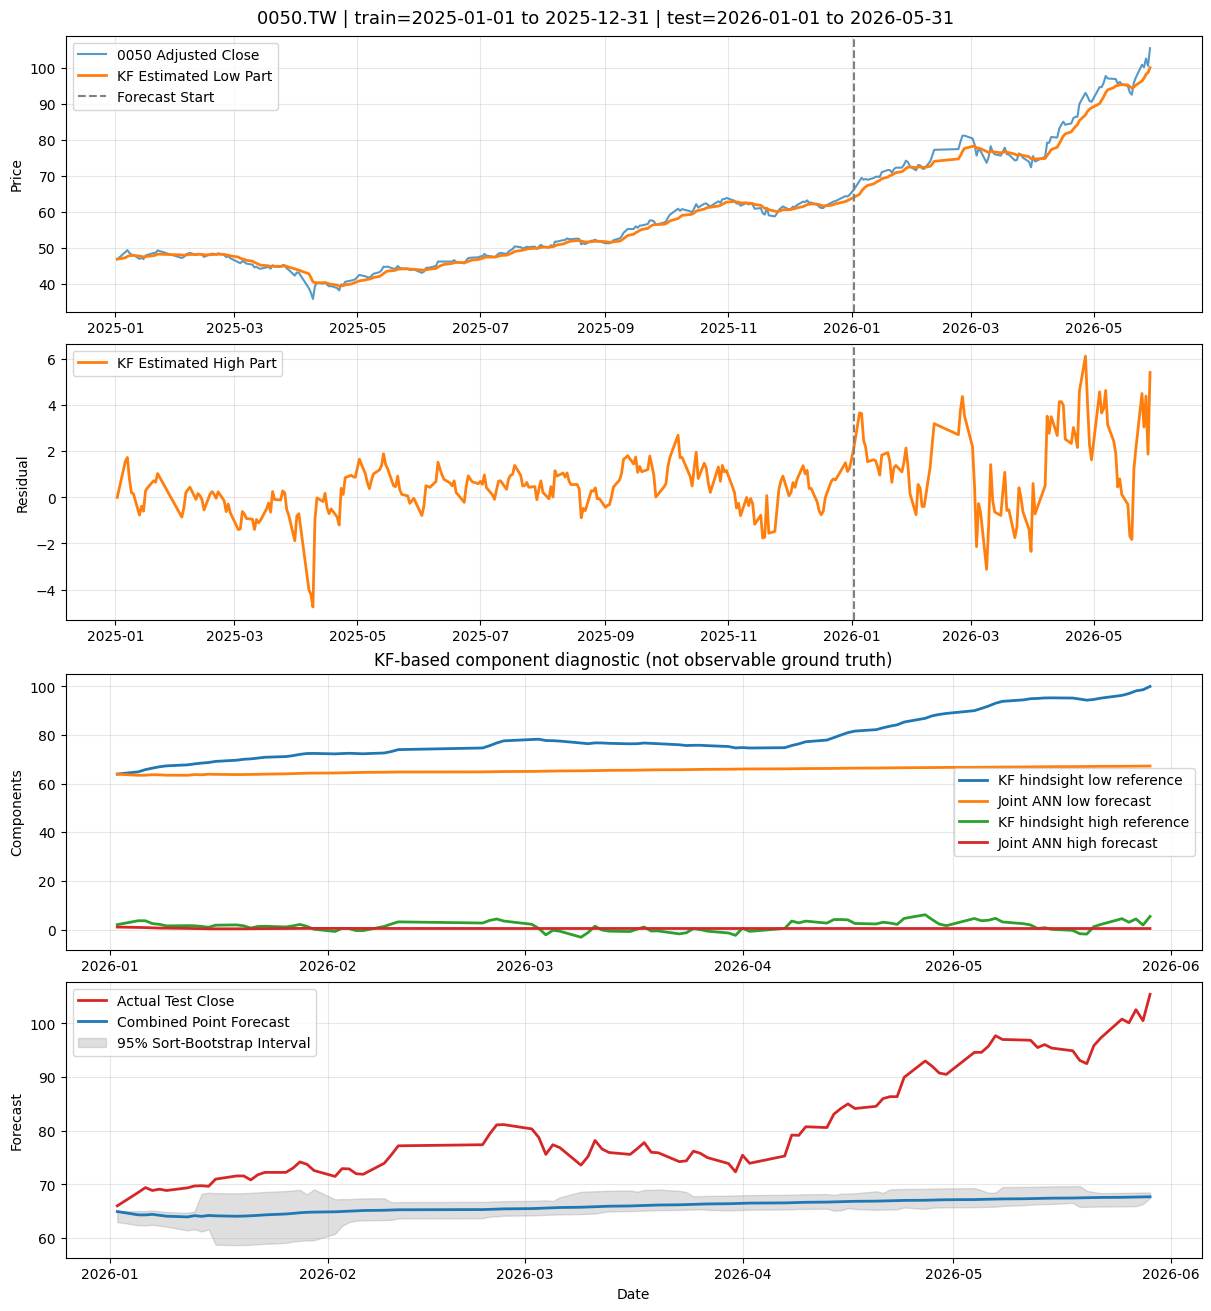

In [7]:
t = pd.to_datetime(result["full_dates"])
t_test = pd.to_datetime(result["test_dates"])
forecast_start = t_test[0]

fig, axes = plt.subplots(4, 1, figsize=(12, 13), constrained_layout=True)
fig.suptitle(
    f'{result["ticker"]} | train={result["train_period"]} | test={result["test_period"]}',
    fontsize=13,
)

axes[0].plot(t, result["measurements"], label="0050 Adjusted Close", alpha=0.75)
axes[0].plot(t, result["estimated_low_full"], label="KF Estimated Low Part", linewidth=2)
axes[0].axvline(forecast_start, color="gray", linestyle="--", label="Forecast Start")
axes[0].set_ylabel("Price")
axes[0].legend(loc="upper left")
axes[0].grid(True, alpha=0.3)

axes[1].plot(t, result["estimated_high_full"], label="KF Estimated High Part", linewidth=2, color="tab:orange")
axes[1].axvline(forecast_start, color="gray", linestyle="--")
axes[1].set_ylabel("Residual")
axes[1].legend(loc="upper left")
axes[1].grid(True, alpha=0.3)

axes[2].plot(t_test, result["reference_low_test"], label="KF hindsight low reference", linewidth=2)
axes[2].plot(t_test, result["low_forecast"], label="Joint ANN low forecast", linewidth=2)
axes[2].plot(t_test, result["reference_high_test"], label="KF hindsight high reference", linewidth=2)
axes[2].plot(t_test, result["high_forecast"], label="Joint ANN high forecast", linewidth=2)
axes[2].set_title("KF-based component diagnostic (not observable ground truth)")
axes[2].set_ylabel("Components")
axes[2].legend(loc="center right")
axes[2].grid(True, alpha=0.3)

axes[3].plot(t_test, result["measurements_test"], label="Actual Test Close", linewidth=2, color="tab:red")
axes[3].plot(t_test, result["final_forecast"], label="Combined Point Forecast", linewidth=2, color="tab:blue")
axes[3].fill_between(
    t_test,
    result["interval_lower"],
    result["interval_upper"],
    color="gray",
    alpha=0.25,
    label="95% Sort-Bootstrap Interval",
)
axes[3].set_ylabel("Forecast")
axes[3].set_xlabel("Date")
axes[3].legend(loc="upper left")
axes[3].grid(True, alpha=0.3)

plt.show()
plt.close(fig)


## Monte Carlo 摘要實驗

這一段會重複執行多次實驗，彙整 MSE、coverage、interval width，以及 component correlation 的平均表現。

In [ ]:
n_monte_carlo = 10
market_data = load_0050_actual_data()
window_grid = [10, 15, 20]
hidden_grid = [16, 32, 64]
validation_horizon = 10
initial_train_size = 120
step_size = 10
bootstrap_replications = 300

np.random.seed(42)
torch.manual_seed(42)
tuning_table, best_params = grid_search_rolling_validation(
    market_data["train_series"],
    window_grid=window_grid,
    hidden_grid=hidden_grid,
    initial_train_size=initial_train_size,
    validation_horizon=validation_horizon,
    step_size=step_size,
    bootstrap_replications=bootstrap_replications,
)

horizon = len(market_data["test_series"])

print("Mode                          : 0050 actual data with rolling validation + sort bootstrap final interval")
print(f"Train period                  : {market_data['train_period']}")
print(f"Test period                   : {market_data['test_period']}")
print(f"Validation best window_size   : {best_params['window_size']}")
print(f"Validation best hidden_size   : {best_params['hidden_size']}")
print(f"Validation horizon            : {validation_horizon}")
print(f"Validation step size          : {step_size}")
print(f"Bootstrap replications        : {bootstrap_replications}")
print(f"Train points                  : {len(market_data['train_series'])}")
print(f"Test points (horizon)         : {horizon}")
print(f"Monte Carlo runs              : {n_monte_carlo}")
print("")
print("Mean low reference MSE | Mean high reference MSE | Mean actual test MSE | Mean actual test RMSE | Mean test std | Mean nRMSE | Mean actual test coverage | Mean interval width")
print("----------------------|-------------------------|----------------------|-----------------------|---------------|------------|---------------------------|--------------------")

start_time = time.perf_counter()
experiment_results = []

for run_idx in range(n_monte_carlo):
    np.random.seed(42 + run_idx)
    torch.manual_seed(42 + run_idx)
    experiment_results.append(
        run_single_experiment(
            window_size=best_params["window_size"],
            hidden_size=best_params["hidden_size"],
            bootstrap_replications=bootstrap_replications,
            market_data=market_data,
            validation_summary={
                "initial_train_size": initial_train_size,
                "validation_horizon": validation_horizon,
                "step_size": step_size,
            },
        )
    )

low_mses = np.array([result["low_mse"] for result in experiment_results], dtype=float)
high_mses = np.array([result["high_mse"] for result in experiment_results], dtype=float)
noisy_mses = np.array([result["final_noisy_mse"] for result in experiment_results], dtype=float)
noisy_rmses = np.array([result["final_noisy_rmse"] for result in experiment_results], dtype=float)
test_stds = np.array([result["test_std"] for result in experiment_results], dtype=float)
normalized_rmses = np.array([result["normalized_rmse"] for result in experiment_results], dtype=float)
noisy_coverages = np.array([result["noisy_coverage"] for result in experiment_results], dtype=float)
mean_interval_widths = np.array([result["mean_interval_width"] for result in experiment_results], dtype=float)
kf_component_corrs = np.array(
    [result["kf_component_corr"]["pearson_corr"] for result in experiment_results],
    dtype=float,
)
kf_component_corrsq = np.array(
    [result["kf_component_corr"]["corr_sq"] for result in experiment_results],
    dtype=float,
)
mean_data_generation = np.mean([result["timing_info"]["data_generation"] for result in experiment_results])
mean_point_forecast_fit = np.mean([result["timing_info"]["point_forecast_fit"] for result in experiment_results])
mean_kf_decomposition = np.mean([result["timing_info"]["kf_decomposition"] for result in experiment_results])
mean_joint_ann_fit_forecast = np.mean(
    [result["timing_info"]["joint_ann_fit_forecast"] for result in experiment_results]
)
mean_residual_pool_build = np.mean(
    [result["timing_info"]["residual_pool_build"] for result in experiment_results]
)
mean_sort_bootstrap_interval = np.mean(
    [result["timing_info"]["sort_bootstrap_interval"] for result in experiment_results]
)
mean_residual_pool_size = np.mean([len(result["residual_pool"]) for result in experiment_results])

print(
    f"{np.mean(low_mses):.4f}                 | "
    f"{np.mean(high_mses):.4f}                  | "
    f"{np.mean(noisy_mses):.4f}               | "
    f"{np.mean(noisy_rmses):.4f}                | "
    f"{np.mean(test_stds):.4f}        | "
    f"{np.mean(normalized_rmses):.4f}     | "
    f"{np.mean(noisy_coverages):.2f}%                    | "
    f"{np.mean(mean_interval_widths):.4f}"
)
print(
    "Avg timing (s/run): "
    f"data={mean_data_generation:.2f}, "
    f"point_fit={mean_point_forecast_fit:.2f}"
)
print(
    "Avg model breakdown (s/run): "
    f"kf={mean_kf_decomposition:.2f}, "
    f"joint_ann={mean_joint_ann_fit_forecast:.2f}, "
    f"res_pool={mean_residual_pool_build:.2f}, "
    f"sort_boot={mean_sort_bootstrap_interval:.2f}"
)
print(
    "Avg component corr: "
    f"KF={np.mean(kf_component_corrs):.4f} "
    f"(R^2={np.mean(kf_component_corrsq):.4f})"
)
print(f"Avg residual pool size        : {mean_residual_pool_size:.1f}")
print("")
print(f"Elapsed time                   : {time.perf_counter() - start_time:.2f} seconds")

representative = experiment_results[0]
t = pd.to_datetime(representative["full_dates"])
t_test = pd.to_datetime(representative["test_dates"])
forecast_start = t_test[0]

fig, axes = plt.subplots(4, 1, figsize=(12, 13), constrained_layout=True)
fig.suptitle(
    f'{representative["ticker"]} | train={representative["train_period"]} | test={representative["test_period"]}',
    fontsize=13,
)

axes[0].plot(t, representative["measurements"], label="0050 Adjusted Close", alpha=0.75)
axes[0].plot(t, representative["estimated_low_full"], label="KF Estimated Low Part", linewidth=2)
axes[0].axvline(forecast_start, color="gray", linestyle="--", label="Forecast Start")
axes[0].set_ylabel("Price")
axes[0].legend(loc="upper left")
axes[0].grid(True, alpha=0.3)

axes[1].plot(t, representative["estimated_high_full"], label="KF Estimated High Part", linewidth=2, color="tab:orange")
axes[1].axvline(forecast_start, color="gray", linestyle="--")
axes[1].set_ylabel("Residual")
axes[1].legend(loc="upper left")
axes[1].grid(True, alpha=0.3)

axes[2].plot(t_test, representative["reference_low_test"], label="KF hindsight low reference", linewidth=2)
axes[2].plot(t_test, representative["low_forecast"], label="Joint ANN low forecast", linewidth=2)
axes[2].plot(t_test, representative["reference_high_test"], label="KF hindsight high reference", linewidth=2)
axes[2].plot(t_test, representative["high_forecast"], label="Joint ANN high forecast", linewidth=2)
axes[2].set_title("KF-based component diagnostic (not observable ground truth)")
axes[2].set_ylabel("Components")
axes[2].legend(loc="center right")
axes[2].grid(True, alpha=0.3)

axes[3].plot(t_test, representative["measurements_test"], label="Actual Test Close", linewidth=2, color="tab:red")
axes[3].plot(t_test, representative["final_forecast"], label="Combined Point Forecast", linewidth=2, color="tab:blue")
axes[3].fill_between(
    t_test,
    representative["interval_lower"],
    representative["interval_upper"],
    color="gray",
    alpha=0.25,
    label="95% Sort-Bootstrap Interval",
)
axes[3].set_ylabel("Forecast")
axes[3].set_xlabel("Date")
axes[3].legend(loc="upper left")
axes[3].grid(True, alpha=0.3)

plt.show()
plt.close(fig)
